In [1]:
# Install the optuna library
!pip install -q optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 4.1 MB/s eta 0:00:00


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Save directory : /content/drive/MyDrive/alibaba_ms/saved_models/gb/

BLOCK 1: LOADING DATASET
  Loaded in      : 3.2s
  Total samples  : 178,930
  Features       : 44
  Violation rate : 5.13%
  Normal         : 169,752
  Violated       : 9,178

BLOCK 2: TEMPORAL SPLITS
  Full dataset     : 178,930 samples
  Subset window    : idx 71572→125250 (53,678 samples, middle 30%)
  Sub train  : 37,574 | Violations: 1882 (5.01%)
  Sub val    : 16,104  | Violations: 823 (5.11%)

  Full train : 135,986 | Violations: 6916 (5.09%)
  Full val   : 33,997  | Violations: 1762 (5.18%)
  Full test  : 8,947  | Violations: 500 (5.59%)

BLOCK 3: NO FEATURE SCALING
  GradientBoostingClassifier is scale-invariant.
  Raw feature arrays used directly — no StandardScaler.
  Subset train shape : (37574, 44)
  Full   train shape : (135986, 44)

BLOCK 4: IMBALANCE HANDLING
  Strategy : sam

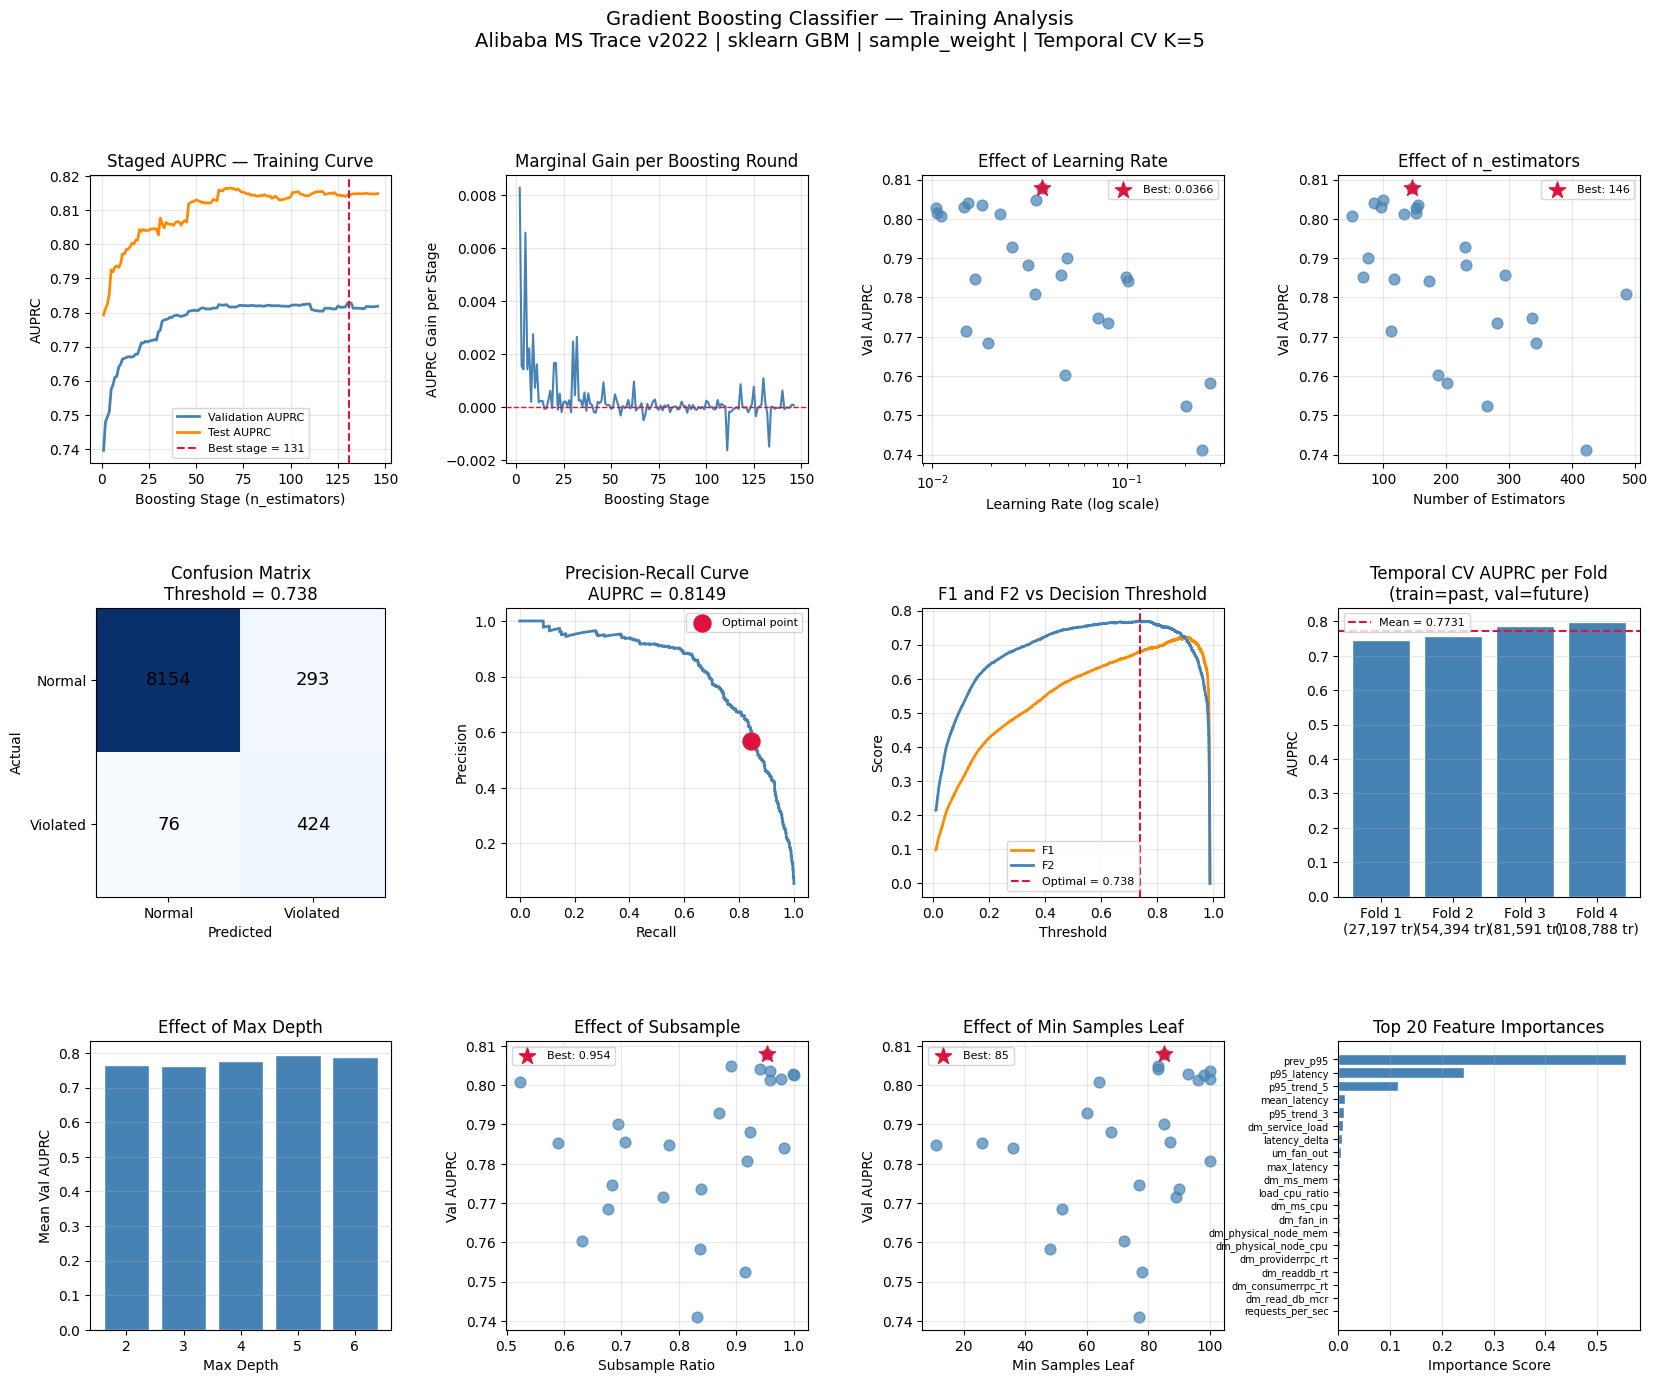

  gb_full_analysis.png : Saved

BLOCK 14: FINAL SUMMARY

  SAVE STRUCTURE:
  /content/drive/MyDrive/alibaba_ms/saved_models/gb/
    gb_best_model.pkl
    best_params.pkl
    all_trial_results.csv
    trial_log.txt
    optuna_study.pkl
    kfold_results.pkl
    feature_importances.csv
    gb_best_summary.json
    gb_full_analysis.png
    gb_trial00.pkl ... gb_trial24.pkl

  MODEL CONFIGURATION:
    Hyperparameter search  : Optuna TPE, 25 trials on temporal subset
    Final training data    : Full train (135,986 samples)
    Imbalance handling     : sample_weight (ratio = 18.66)
    Cross-validation       : Temporal K-Fold K=5
    Threshold optimisation : F2-optimal on full validation set

  BEST HYPERPARAMETERS:
    n_estimators          : 146
    learning_rate         : 0.03663642658392902
    max_depth             : 6
    subsample             : 0.9536029446516603
    min_samples_leaf      : 85
    best_boosting_stage   : 131 / 146

  VALIDATION METRICS (full validation set):
    Val 

In [4]:
import os, json, warnings, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import joblib
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import (
    average_precision_score, roc_auc_score,
    f1_score, fbeta_score,
    precision_score, recall_score,
    classification_report, confusion_matrix,
    precision_recall_curve
)
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)
warnings.filterwarnings('ignore')

from google.colab import drive
drive.mount('/content/drive')

FILE_PATH = '/content/drive/MyDrive/ml/Final_Topology_Dataset_FULL_0_to_5__2.csv'
SAVE_DIR  = '/content/drive/MyDrive/alibaba_ms/saved_models/gb/'
os.makedirs(SAVE_DIR, exist_ok=True)

print(f"Save directory : {SAVE_DIR}")


# ─────────────────────────────────────────────────────────────
# BLOCK 1: LOAD DATASET
# ─────────────────────────────────────────────────────────────

print("\n" + "=" * 60)
print("BLOCK 1: LOADING DATASET")
print("=" * 60)

t0 = time.time()
df = pd.read_csv(FILE_PATH)
df = df.sort_values('time_window').reset_index(drop=True)

NON_FEATURE_COLS = ['um', 'dm', 'time_window', 'violation_next_window']
FEATURE_COLS     = [c for c in df.columns if c not in NON_FEATURE_COLS]
TARGET           = 'violation_next_window'

X = df[FEATURE_COLS].fillna(-1).values.astype(np.float32)
y = df[TARGET].values.astype(np.float32)

print(f"  Loaded in      : {time.time()-t0:.1f}s")
print(f"  Total samples  : {len(df):,}")
print(f"  Features       : {len(FEATURE_COLS)}")
print(f"  Violation rate : {y.mean()*100:.2f}%")
print(f"  Normal         : {int((y==0).sum()):,}")
print(f"  Violated       : {int((y==1).sum()):,}")


# ─────────────────────────────────────────────────────────────
# BLOCK 2: TEMPORAL SPLITS
#
# Two sets of splits are prepared.
#
# (a) Subset — middle 30% of the dataset (idx 40%→70%).
#     Used exclusively for Optuna hyperparameter search.
#     This window sits well within the trace, away from the
#     cold-start first 40% and the val-adjacent last 30%,
#     ensuring the hyperparameter search reflects stable,
#     representative operating conditions without leaking
#     proximity to the final evaluation window.
#     Internal split: 70% train | 30% val (no test needed —
#     test evaluation is done on the full held-out test set).
#
# (b) Full dataset — entire trace in temporal order.
#     Used for final model training, threshold optimisation,
#     cross-validation, and all reported evaluation metrics.
#     Split: 80% of first 95% as train | 15% of 95% as val
#            | last 5% as test.
#
# All splits are strictly temporal — no shuffling at any stage.
# ─────────────────────────────────────────────────────────────

print("\n" + "=" * 60)
print("BLOCK 2: TEMPORAL SPLITS")
print("=" * 60)

n = len(df)

# ── Subset splits (Optuna search) ────────────────────────────
sub_start = int(n * 0.40)
sub_end   = int(n * 0.70)
X_sub     = X[sub_start:sub_end]
y_sub     = y[sub_start:sub_end]
n_sub     = len(X_sub)

sub_val_start  = int(n_sub * 0.70)

X_sub_tr_raw = X_sub[:sub_val_start]
y_sub_tr     = y_sub[:sub_val_start]
X_sub_vl_raw = X_sub[sub_val_start:]
y_sub_vl     = y_sub[sub_val_start:]

assert y_sub_tr.sum() > 0, "No violations in subset train — adjust window"
assert y_sub_vl.sum() > 0, "No violations in subset val   — adjust window"

print(f"  Full dataset     : {n:,} samples")
print(f"  Subset window    : idx {sub_start}→{sub_end} ({n_sub:,} samples, middle 30%)")
print(f"  Sub train  : {len(X_sub_tr_raw):,} | Violations: {y_sub_tr.sum():.0f} ({y_sub_tr.mean()*100:.2f}%)")
print(f"  Sub val    : {len(X_sub_vl_raw):,}  | Violations: {y_sub_vl.sum():.0f} ({y_sub_vl.mean()*100:.2f}%)")

# ── Full splits (final model) ─────────────────────────────────
test_start_f = int(n * 0.95)
val_start_f  = int(n * 0.95 * 0.80)

X_tr_raw = X[:val_start_f]
y_tr     = y[:val_start_f]
X_vl_raw = X[val_start_f:test_start_f]
y_vl     = y[val_start_f:test_start_f]
X_te_raw = X[test_start_f:]
y_te     = y[test_start_f:]

print(f"\n  Full train : {len(X_tr_raw):,} | Violations: {y_tr.sum():.0f} ({y_tr.mean()*100:.2f}%)")
print(f"  Full val   : {len(X_vl_raw):,}  | Violations: {y_vl.sum():.0f} ({y_vl.mean()*100:.2f}%)")
print(f"  Full test  : {len(X_te_raw):,}  | Violations: {y_te.sum():.0f} ({y_te.mean()*100:.2f}%)")


# ─────────────────────────────────────────────────────────────
# BLOCK 3: NO FEATURE SCALING
#
# GradientBoostingClassifier builds decision trees. Trees split
# on feature thresholds and are invariant to monotonic
# transformations of the input — scaling x by any constant
# produces identical splits and identical model behaviour.
# StandardScaler is therefore omitted. Raw feature arrays
# are used directly in all partitions.
# ─────────────────────────────────────────────────────────────

print("\n" + "=" * 60)
print("BLOCK 3: NO FEATURE SCALING")
print("=" * 60)
print("  GradientBoostingClassifier is scale-invariant.")
print("  Raw feature arrays used directly — no StandardScaler.")

X_sub_tr = X_sub_tr_raw
X_sub_vl = X_sub_vl_raw

X_tr     = X_tr_raw
X_vl     = X_vl_raw
X_te     = X_te_raw

print(f"  Subset train shape : {X_sub_tr.shape}")
print(f"  Full   train shape : {X_tr.shape}")


# ─────────────────────────────────────────────────────────────
# BLOCK 4: IMBALANCE HANDLING — sample_weight
#
# GradientBoostingClassifier accepts sample_weight in .fit().
# Minority (violation) samples receive a weight equal to the
# neg/pos ratio; majority samples receive weight 1.0.
# This scales the contribution of minority samples to each
# tree's split criterion in proportion to the imbalance ratio.
#
# No undersampling. No synthetic oversampling. The full
# temporal sequence is preserved in all partitions.
# Sample weights are computed independently for the subset
# train partition (used during Optuna) and the full train
# partition (used for the final model and each CV fold).
# ─────────────────────────────────────────────────────────────

print("\n" + "=" * 60)
print("BLOCK 4: IMBALANCE HANDLING")
print("=" * 60)
print("  Strategy : sample_weight in GradientBoostingClassifier.fit()")
print("             All samples retained. Temporal order preserved.")

def make_sample_weights(y_arr):
    neg   = (y_arr == 0).sum()
    pos   = (y_arr == 1).sum()
    ratio = neg / pos
    w     = np.where(y_arr == 1, ratio, 1.0)
    return w, ratio

sub_sw,  sub_ratio  = make_sample_weights(y_sub_tr)
full_sw, full_ratio = make_sample_weights(y_tr)

print(f"  Subset train — Normal: {int((y_sub_tr==0).sum()):,} | Violated: {int((y_sub_tr==1).sum()):,} | weight ratio: {sub_ratio:.2f}")
print(f"  Full   train — Normal: {int((y_tr==0).sum()):,} | Violated: {int((y_tr==1).sum()):,} | weight ratio: {full_ratio:.2f}")


# ─────────────────────────────────────────────────────────────
# BLOCK 5: OPTUNA HYPERPARAMETER SEARCH — 25 TRIALS ON SUBSET
#
# All 25 trials run on the temporal subset (train/val only).
# The val partition is strictly later in time than train.
# sample_weight is applied in every .fit() call.
#
# Search space:
#   n_estimators     [50, 500]    — number of boosting rounds
#   learning_rate    [0.01, 0.3]  — shrinkage, log scale
#   max_depth        [2, 6]       — tree depth; GB is sensitive
#                                   to overly deep trees
#   subsample        [0.5, 1.0]   — stochastic GB row fraction
#   min_samples_leaf [10, 100]    — minimum leaf size;
#                                   primary regularisation knob
#                                   for imbalanced tabular data
# ─────────────────────────────────────────────────────────────

print("\n" + "=" * 60)
print("BLOCK 5: OPTUNA HYPERPARAMETER SEARCH — 25 TRIALS")
print("=" * 60)
print("  Sampler    : TPE")
print("  Objective  : Maximize subset Val AUPRC")
print("  Data       : subset train / val (temporal, no shuffle)")
print("  Imbalance  : sample_weight in every .fit() call")
print("  Parameters : n_estimators, learning_rate, max_depth,")
print("               subsample, min_samples_leaf")
print("-" * 60)

all_trial_results = []


def objective(trial):
    n_estimators     = trial.suggest_int('n_estimators',      50,  500)
    learning_rate    = trial.suggest_float('learning_rate',   0.01, 0.3, log=True)
    max_depth        = trial.suggest_int('max_depth',         2,   6)
    subsample        = trial.suggest_float('subsample',       0.5, 1.0)
    min_samples_leaf = trial.suggest_int('min_samples_leaf',  10,  100)

    print(f"\n  Trial {trial.number+1:02d}/25 | "
          f"n_est={n_estimators} lr={learning_rate:.4f} "
          f"depth={max_depth} sub={subsample:.2f} "
          f"min_leaf={min_samples_leaf}")

    model = GradientBoostingClassifier(
        n_estimators     = n_estimators,
        learning_rate    = learning_rate,
        max_depth        = max_depth,
        subsample        = subsample,
        min_samples_leaf = min_samples_leaf,
        random_state     = 42,
        verbose          = 0
    )

    t0 = time.time()
    model.fit(X_sub_tr, y_sub_tr, sample_weight=sub_sw)
    elapsed = time.time() - t0

    val_probs = model.predict_proba(X_sub_vl)[:, 1]
    val_auprc = average_precision_score(y_sub_vl, val_probs)
    val_auroc = roc_auc_score(y_sub_vl, val_probs)

    print(f"  Trial {trial.number+1:02d}/25 | "
          f"Val AUPRC: {val_auprc:.4f} | "
          f"Val AUROC: {val_auroc:.4f} | "
          f"Time: {elapsed:.0f}s")

    trial_name = (
        f"gb_trial{trial.number:02d}"
        f"_est{n_estimators}_d{max_depth}"
        f"_lr{learning_rate:.4f}"
    )
    joblib.dump(model, SAVE_DIR + trial_name + '.pkl')

    all_trial_results.append({
        'trial'           : trial.number,
        'n_estimators'    : n_estimators,
        'learning_rate'   : round(learning_rate, 6),
        'max_depth'       : max_depth,
        'subsample'       : round(subsample, 3),
        'min_samples_leaf': min_samples_leaf,
        'val_auprc'       : round(val_auprc, 4),
        'val_auroc'       : round(val_auroc, 4),
        'trial_time_sec'  : round(elapsed, 1),
        'model_file'      : trial_name + '.pkl'
    })

    return val_auprc


study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=25)

print("\n" + "=" * 60)
print("OPTUNA SEARCH COMPLETE")
print(f"  Best Val AUPRC : {study.best_value:.4f}")
print(f"  Best Trial     : {study.best_trial.number + 1}")
print("  Best Params    :")
for k, v in study.best_params.items():
    print(f"    {k:<22}: {v}")
print("=" * 60)


# ─────────────────────────────────────────────────────────────
# BLOCK 6: TRIAL RESULTS TABLE
# ─────────────────────────────────────────────────────────────

print("\n" + "=" * 60)
print("BLOCK 6: TRIAL RESULTS")
print("=" * 60)

results_df = pd.DataFrame(all_trial_results).sort_values(
    'val_auprc', ascending=False
).reset_index(drop=True)

results_df.to_csv(SAVE_DIR + 'all_trial_results.csv', index=False)

print("\nALL TRIALS RANKED BY VAL AUPRC:")
print("-" * 90)
print(results_df[[
    'trial', 'n_estimators', 'learning_rate', 'max_depth',
    'subsample', 'min_samples_leaf', 'val_auprc', 'val_auroc'
]].to_string(index=False))

with open(SAVE_DIR + 'trial_log.txt', 'w') as f:
    f.write("GRADIENT BOOSTING HYPERPARAMETER TUNING LOG\n")
    f.write("Dataset    : Alibaba MS Trace v2022\n")
    f.write("Model      : sklearn GradientBoostingClassifier\n")
    f.write("Imbalance  : sample_weight — no undersampling\n")
    f.write("Splits     : temporal — no shuffle\n")
    f.write("Optuna data: subset (middle 30% of trace, idx 40%→70%)\n")
    f.write("Trials     : 25 | Metric : Val AUPRC\n")
    f.write("=" * 70 + "\n\n")
    for _, row in results_df.iterrows():
        f.write(f"TRIAL {int(row['trial']):02d} | Val AUPRC: {row['val_auprc']} | AUROC: {row['val_auroc']}\n")
        f.write(f"  n_estimators     : {row['n_estimators']}\n")
        f.write(f"  learning_rate    : {row['learning_rate']}\n")
        f.write(f"  max_depth        : {row['max_depth']}\n")
        f.write(f"  subsample        : {row['subsample']}\n")
        f.write(f"  min_samples_leaf : {row['min_samples_leaf']}\n")
        f.write(f"  time (sec)       : {row['trial_time_sec']}\n")
        f.write("-" * 50 + "\n")
    f.write(f"\nBEST TRIAL : {results_df.iloc[0]['trial']}\n")
    f.write(f"BEST AUPRC : {results_df.iloc[0]['val_auprc']}\n")

joblib.dump(study, SAVE_DIR + 'optuna_study.pkl')
print("  all_trial_results.csv : Saved")
print("  trial_log.txt         : Saved")
print("  optuna_study.pkl      : Saved")


# ─────────────────────────────────────────────────────────────
# BLOCK 7: RETRAIN BEST MODEL ON FULL TRAINING DATA
#
# The best hyperparameters from Optuna are applied to a model
# trained on the full training partition (all data before the
# val split). full_sw sample weights are used throughout.
# This is the model used for all reported evaluation metrics.
# ─────────────────────────────────────────────────────────────

print("\n" + "=" * 60)
print("BLOCK 7: RETRAINING BEST MODEL ON FULL TRAINING DATA")
print("=" * 60)

bp = study.best_params
print(f"  n_estimators     : {bp['n_estimators']}")
print(f"  learning_rate    : {bp['learning_rate']:.6f}")
print(f"  max_depth        : {bp['max_depth']}")
print(f"  subsample        : {bp['subsample']:.3f}")
print(f"  min_samples_leaf : {bp['min_samples_leaf']}")
print(f"  Training samples : {len(X_tr):,}")
print(f"  Sample weight    : {full_ratio:.4f} (minority class)")

t0 = time.time()
best_model = GradientBoostingClassifier(
    n_estimators     = bp['n_estimators'],
    learning_rate    = bp['learning_rate'],
    max_depth        = bp['max_depth'],
    subsample        = bp['subsample'],
    min_samples_leaf = bp['min_samples_leaf'],
    random_state     = 42,
    verbose          = 0
)
best_model.fit(X_tr, y_tr, sample_weight=full_sw)
train_time = time.time() - t0

val_probs_best = best_model.predict_proba(X_vl)[:, 1]
best_val_auprc = average_precision_score(y_vl, val_probs_best)
best_val_auroc = roc_auc_score(y_vl, val_probs_best)

print(f"  Training time    : {train_time:.1f}s")
print(f"  Val AUPRC        : {best_val_auprc:.4f}")
print(f"  Val AUROC        : {best_val_auroc:.4f}")

joblib.dump(best_model, SAVE_DIR + 'gb_best_model.pkl')
joblib.dump(bp,         SAVE_DIR + 'best_params.pkl')
print("  gb_best_model.pkl : Saved")
print("  best_params.pkl   : Saved")


# ─────────────────────────────────────────────────────────────
# BLOCK 8: STAGED PREDICTION — TRAINING CURVE
#
# staged_predict_proba yields one probability matrix per
# boosting round. AUPRC is computed at every stage on both
# the full val and full test partitions, producing a training
# curve that shows how predictive performance evolves with
# additional trees.
#
# best_stage is the stage with the highest val AUPRC.
# The difference between val and test AUPRC at best_stage
# quantifies the degree of temporal distribution shift
# between the val and test windows.
# ─────────────────────────────────────────────────────────────

print("\n" + "=" * 60)
print("BLOCK 8: STAGED PREDICTION — TRAINING CURVE")
print("=" * 60)
print("  Computing staged AUPRC across all boosting rounds...")

val_auprc_curve  = []
test_auprc_curve = []

for val_pred in best_model.staged_predict_proba(X_vl):
    val_auprc_curve.append(average_precision_score(y_vl, val_pred[:, 1]))

for test_pred in best_model.staged_predict_proba(X_te):
    test_auprc_curve.append(average_precision_score(y_te, test_pred[:, 1]))

stages     = np.arange(1, len(val_auprc_curve) + 1)
best_stage = int(np.argmax(val_auprc_curve)) + 1

print(f"  Total stages              : {len(stages)}")
print(f"  Best val stage            : {best_stage}")
print(f"  Val  AUPRC at best stage  : {val_auprc_curve[best_stage-1]:.4f}")
print(f"  Test AUPRC at best stage  : {test_auprc_curve[best_stage-1]:.4f}")
print(f"  Val  AUPRC at final stage : {val_auprc_curve[-1]:.4f}")
print(f"  Test AUPRC at final stage : {test_auprc_curve[-1]:.4f}")


# ─────────────────────────────────────────────────────────────
# BLOCK 9: TEMPORAL K-FOLD CROSS VALIDATION (K=5)
#
# Cross-validation is performed on the full training partition.
# For fold i (i = 1 .. K-1):
#   train = windows in folds 0..i-1   (strictly the past)
#   val   = windows in fold i          (strictly the future)
#
# This mirrors production conditions: the model is trained on
# historical windows only and evaluated on the window that
# immediately follows. No future information is available
# during training at any fold.
#
# sample_weight is recomputed per fold from that fold's train
# partition. Violation rate varies across time periods in the
# Alibaba trace; a single global weight would be
# miscalibrated for folds covering different time windows.
# ─────────────────────────────────────────────────────────────

print("\n" + "=" * 60)
print("BLOCK 9: TEMPORAL K-FOLD CROSS VALIDATION (K=5)")
print("=" * 60)
print("  Method : train = past folds | val = strictly next fold")
print("  Data   : full training partition")
print("  sample_weight recomputed per fold")
print("-" * 60)

K            = 5
n_tr         = len(X_tr)
fold_size    = n_tr // K
fold_auprcs  = []
fold_aurocs  = []
fold_details = []

for fold_num in range(1, K):
    tr_end   = fold_num * fold_size
    vl_start = fold_num * fold_size
    vl_end   = min((fold_num + 1) * fold_size, n_tr)

    Xf_tr = X_tr[:tr_end];         yf_tr = y_tr[:tr_end]
    Xf_vl = X_tr[vl_start:vl_end]; yf_vl = y_tr[vl_start:vl_end]

    fold_pos = (yf_tr == 1).sum()
    if fold_pos == 0:
        print(f"  Fold {fold_num}/{K-1} skipped — no violations in train partition")
        continue

    fold_sw, fold_ratio = make_sample_weights(yf_tr)
    vl_pos = (yf_vl == 1).sum()

    print(f"\n  Fold {fold_num}/{K-1} | "
          f"train 0..{tr_end-1} ({tr_end:,}) | "
          f"val {vl_start}..{vl_end-1} ({vl_end-vl_start:,}) | "
          f"violations={int(vl_pos)} | sw_ratio={fold_ratio:.2f}")

    fold_model = GradientBoostingClassifier(
        n_estimators     = bp['n_estimators'],
        learning_rate    = bp['learning_rate'],
        max_depth        = bp['max_depth'],
        subsample        = bp['subsample'],
        min_samples_leaf = bp['min_samples_leaf'],
        random_state     = 42,
        verbose          = 0
    )
    t0 = time.time()
    fold_model.fit(Xf_tr, yf_tr, sample_weight=fold_sw)
    elapsed = time.time() - t0

    fold_probs = fold_model.predict_proba(Xf_vl)[:, 1]
    fa = average_precision_score(yf_vl, fold_probs)
    fr = roc_auc_score(yf_vl, fold_probs)

    fold_auprcs.append(fa)
    fold_aurocs.append(fr)
    fold_details.append({
        'fold'          : fold_num,
        'train_samples' : tr_end,
        'val_samples'   : vl_end - vl_start,
        'val_viol_pct'  : round(vl_pos / len(yf_vl) * 100, 2),
        'sw_ratio'      : round(fold_ratio, 3),
        'auprc'         : round(fa, 4),
        'auroc'         : round(fr, 4),
        'time_sec'      : round(elapsed, 1)
    })
    print(f"  Fold {fold_num}/{K-1} | AUPRC={fa:.4f} | AUROC={fr:.4f} | {elapsed:.0f}s")

print(f"\n  Temporal K-Fold AUPRC : {[round(x,4) for x in fold_auprcs]}")
if fold_auprcs:
    print(f"  Mean AUPRC            : {np.mean(fold_auprcs):.4f} +/- {np.std(fold_auprcs):.4f}")

joblib.dump({
    'fold_auprcs'  : fold_auprcs,
    'fold_aurocs'  : fold_aurocs,
    'mean_auprc'   : float(np.mean(fold_auprcs)) if fold_auprcs else None,
    'std_auprc'    : float(np.std(fold_auprcs))  if fold_auprcs else None,
    'fold_details' : fold_details
}, SAVE_DIR + 'kfold_results.pkl')
print("  kfold_results.pkl : Saved")


# ─────────────────────────────────────────────────────────────
# BLOCK 10: THRESHOLD OPTIMISATION
#
# The decision threshold is optimised on the full validation
# set by maximising F2 score. F2 weights recall twice over
# precision — appropriate for SLA violation detection where
# a false negative (missed violation) carries higher
# operational cost than a false positive. The F1-optimal
# threshold is also computed for reference.
# ─────────────────────────────────────────────────────────────

print("\n" + "=" * 60)
print("BLOCK 10: THRESHOLD OPTIMISATION")
print("=" * 60)
print("  Metric : F2 Score on full validation set")

precision_vals, recall_vals, thresholds = precision_recall_curve(
    y_vl, val_probs_best
)

f2_scores = np.array([
    fbeta_score(y_vl, (val_probs_best >= t).astype(int),
                beta=2, zero_division=0)
    for t in thresholds
])
f1_scores = np.array([
    f1_score(y_vl, (val_probs_best >= t).astype(int),
             zero_division=0)
    for t in thresholds
])

best_thresh    = thresholds[np.argmax(f2_scores)]
best_f1_thresh = thresholds[np.argmax(f1_scores)]

print(f"  Optimal threshold (F2) : {best_thresh:.4f}")
print(f"  Optimal threshold (F1) : {best_f1_thresh:.4f}")
print(f"  Val F2 at optimal      : {f2_scores.max():.4f}")
print(f"  Val F1 at optimal      : {f1_scores.max():.4f}")


# ─────────────────────────────────────────────────────────────
# BLOCK 11: FINAL TEST SET EVALUATION
# ─────────────────────────────────────────────────────────────

print("\n" + "=" * 60)
print("BLOCK 11: FINAL TEST SET EVALUATION")
print("=" * 60)

test_probs     = best_model.predict_proba(X_te)[:, 1]
test_preds_05  = (test_probs >= 0.50).astype(int)
test_preds_opt = (test_probs >= best_thresh).astype(int)

test_auprc  = average_precision_score(y_te, test_probs)
test_auroc  = roc_auc_score(y_te, test_probs)
prec_opt    = precision_score(y_te, test_preds_opt, zero_division=0)
rec_opt     = recall_score(y_te, test_preds_opt, zero_division=0)
prec_05     = precision_score(y_te, test_preds_05, zero_division=0)
rec_05      = recall_score(y_te, test_preds_05, zero_division=0)
f1_05       = f1_score(y_te, test_preds_05,  zero_division=0)
f2_05       = fbeta_score(y_te, test_preds_05,  beta=2, zero_division=0)
f1_opt      = f1_score(y_te, test_preds_opt, zero_division=0)
f2_opt      = fbeta_score(y_te, test_preds_opt, beta=2, zero_division=0)
acc_05      = (test_preds_05  == y_te).mean()
acc_opt     = (test_preds_opt == y_te).mean()

print(f"\n  {'Metric':<22} {'Threshold=0.50':>16} {'Optimal ({:.3f})'.format(best_thresh):>18}")
print(f"  {'─'*58}")
print(f"  {'AUPRC':<22} {'N/A':>16} {test_auprc:>18.4f}")
print(f"  {'AUROC':<22} {'N/A':>16} {test_auroc:>18.4f}")
print(f"  {'Precision':<22} {prec_05:>16.4f} {prec_opt:>18.4f}")
print(f"  {'Recall':<22} {rec_05:>16.4f} {rec_opt:>18.4f}")
print(f"  {'F1 Score':<22} {f1_05:>16.4f} {f1_opt:>18.4f}")
print(f"  {'F2 Score':<22} {f2_05:>16.4f} {f2_opt:>18.4f}")
print(f"  {'Accuracy':<22} {acc_05:>16.4f} {acc_opt:>18.4f}")
print(f"\n  Classification Report at Optimal Threshold:")
print(classification_report(y_te, test_preds_opt, zero_division=0))


# ─────────────────────────────────────────────────────────────
# BLOCK 12: FEATURE IMPORTANCE
# ─────────────────────────────────────────────────────────────

print("\n" + "=" * 60)
print("BLOCK 12: FEATURE IMPORTANCE (TOP 20)")
print("=" * 60)

feat_imp_df = pd.DataFrame({
    'feature'   : FEATURE_COLS,
    'importance': best_model.feature_importances_
}).sort_values('importance', ascending=False).reset_index(drop=True)

print(feat_imp_df.head(20).to_string(index=False))
feat_imp_df.to_csv(SAVE_DIR + 'feature_importances.csv', index=False)
print("  feature_importances.csv : Saved")


# ─────────────────────────────────────────────────────────────
# BLOCK 13: VISUALIZATION
# ─────────────────────────────────────────────────────────────

print("\n" + "=" * 60)
print("BLOCK 13: GENERATING PLOTS")
print("=" * 60)

best_row = results_df.iloc[0]

fig = plt.figure(figsize=(20, 15))
fig.suptitle(
    'Gradient Boosting Classifier — Training Analysis\n'
    'Alibaba MS Trace v2022 | sklearn GBM | sample_weight | Temporal CV K=5',
    fontsize=14, y=0.99
)
gs = gridspec.GridSpec(3, 4, figure=fig, hspace=0.5, wspace=0.38)

# ── Row 0 ────────────────────────────────────────────────────

ax1 = fig.add_subplot(gs[0, 0])
ax1.plot(stages, val_auprc_curve,  color='steelblue',  lw=2, label='Validation AUPRC')
ax1.plot(stages, test_auprc_curve, color='darkorange', lw=2, label='Test AUPRC')
ax1.axvline(x=best_stage, color='crimson', ls='--',
            label=f'Best stage = {best_stage}')
ax1.set_xlabel('Boosting Stage (n_estimators)')
ax1.set_ylabel('AUPRC')
ax1.set_title('Staged AUPRC — Training Curve')
ax1.legend(fontsize=8); ax1.grid(True, alpha=0.3)

ax2 = fig.add_subplot(gs[0, 1])
delta = np.diff(val_auprc_curve)
ax2.plot(stages[1:], delta, color='steelblue', lw=1.5)
ax2.axhline(y=0, color='crimson', ls='--', lw=1)
ax2.set_xlabel('Boosting Stage')
ax2.set_ylabel('AUPRC Gain per Stage')
ax2.set_title('Marginal Gain per Boosting Round')
ax2.grid(True, alpha=0.3)

ax3 = fig.add_subplot(gs[0, 2])
ax3.scatter(results_df['learning_rate'], results_df['val_auprc'],
            alpha=0.7, color='steelblue', s=60)
ax3.scatter(best_row['learning_rate'], best_row['val_auprc'],
            color='crimson', s=150, zorder=5, marker='*',
            label=f"Best: {best_row['learning_rate']:.4f}")
ax3.set_xscale('log')
ax3.set_xlabel('Learning Rate (log scale)')
ax3.set_ylabel('Val AUPRC')
ax3.set_title('Effect of Learning Rate')
ax3.legend(fontsize=8); ax3.grid(True, alpha=0.3)

ax4 = fig.add_subplot(gs[0, 3])
ax4.scatter(results_df['n_estimators'], results_df['val_auprc'],
            alpha=0.7, color='steelblue', s=60)
ax4.scatter(best_row['n_estimators'], best_row['val_auprc'],
            color='crimson', s=150, zorder=5, marker='*',
            label=f"Best: {best_row['n_estimators']}")
ax4.set_xlabel('Number of Estimators')
ax4.set_ylabel('Val AUPRC')
ax4.set_title('Effect of n_estimators')
ax4.legend(fontsize=8); ax4.grid(True, alpha=0.3)

# ── Row 1 ────────────────────────────────────────────────────

ax5 = fig.add_subplot(gs[1, 0])
cm = confusion_matrix(y_te, test_preds_opt)
ax5.imshow(cm, cmap='Blues')
ax5.set_xticks([0,1]); ax5.set_yticks([0,1])
ax5.set_xticklabels(['Normal', 'Violated'])
ax5.set_yticklabels(['Normal', 'Violated'])
ax5.set_xlabel('Predicted'); ax5.set_ylabel('Actual')
ax5.set_title(f'Confusion Matrix\nThreshold = {best_thresh:.3f}')
for i in range(2):
    for j in range(2):
        ax5.text(j, i, str(cm[i,j]), ha='center', va='center', fontsize=13)

ax6 = fig.add_subplot(gs[1, 1])
prec_c, rec_c, _ = precision_recall_curve(y_te, test_probs)
ax6.plot(rec_c, prec_c, color='steelblue', lw=2)
ax6.scatter(recall_vals[np.argmax(f2_scores)],
            precision_vals[np.argmax(f2_scores)],
            color='crimson', s=150, zorder=5, label='Optimal point')
ax6.set_xlabel('Recall'); ax6.set_ylabel('Precision')
ax6.set_title(f'Precision-Recall Curve\nAUPRC = {test_auprc:.4f}')
ax6.legend(fontsize=8); ax6.grid(True, alpha=0.3)

ax7 = fig.add_subplot(gs[1, 2])
ax7.plot(thresholds, f1_scores, color='darkorange', lw=2, label='F1')
ax7.plot(thresholds, f2_scores, color='steelblue',  lw=2, label='F2')
ax7.axvline(x=best_thresh, color='crimson', ls='--',
            label=f'Optimal = {best_thresh:.3f}')
ax7.set_xlabel('Threshold'); ax7.set_ylabel('Score')
ax7.set_title('F1 and F2 vs Decision Threshold')
ax7.legend(fontsize=8); ax7.grid(True, alpha=0.3)

ax8 = fig.add_subplot(gs[1, 3])
fold_labels = [f'Fold {d["fold"]}\n({d["train_samples"]:,} tr)' for d in fold_details]
ax8.bar(fold_labels, fold_auprcs, color='steelblue', edgecolor='white')
ax8.axhline(y=np.mean(fold_auprcs), color='crimson', ls='--',
            label=f'Mean = {np.mean(fold_auprcs):.4f}')
ax8.set_ylabel('AUPRC')
ax8.set_title('Temporal CV AUPRC per Fold\n(train=past, val=future)')
ax8.legend(fontsize=8); ax8.grid(True, alpha=0.3, axis='y')

# ── Row 2 ────────────────────────────────────────────────────

ax9 = fig.add_subplot(gs[2, 0])
dg = results_df.groupby('max_depth')['val_auprc'].mean().reset_index()
ax9.bar(dg['max_depth'].astype(str), dg['val_auprc'],
        color='steelblue', edgecolor='white')
ax9.set_xlabel('Max Depth')
ax9.set_ylabel('Mean Val AUPRC')
ax9.set_title('Effect of Max Depth')
ax9.grid(True, alpha=0.3, axis='y')

ax10 = fig.add_subplot(gs[2, 1])
ax10.scatter(results_df['subsample'], results_df['val_auprc'],
             alpha=0.7, color='steelblue', s=60)
ax10.scatter(best_row['subsample'], best_row['val_auprc'],
             color='crimson', s=150, zorder=5, marker='*',
             label=f"Best: {best_row['subsample']:.3f}")
ax10.set_xlabel('Subsample Ratio')
ax10.set_ylabel('Val AUPRC')
ax10.set_title('Effect of Subsample')
ax10.legend(fontsize=8); ax10.grid(True, alpha=0.3)

ax11 = fig.add_subplot(gs[2, 2])
ax11.scatter(results_df['min_samples_leaf'], results_df['val_auprc'],
             alpha=0.7, color='steelblue', s=60)
ax11.scatter(best_row['min_samples_leaf'], best_row['val_auprc'],
             color='crimson', s=150, zorder=5, marker='*',
             label=f"Best: {best_row['min_samples_leaf']}")
ax11.set_xlabel('Min Samples Leaf')
ax11.set_ylabel('Val AUPRC')
ax11.set_title('Effect of Min Samples Leaf')
ax11.legend(fontsize=8); ax11.grid(True, alpha=0.3)

ax12 = fig.add_subplot(gs[2, 3])
top20 = feat_imp_df.head(20)
ax12.barh(top20['feature'][::-1], top20['importance'][::-1],
          color='steelblue', edgecolor='white')
ax12.set_xlabel('Importance Score')
ax12.set_title('Top 20 Feature Importances')
ax12.tick_params(axis='y', labelsize=7)
ax12.grid(True, alpha=0.3, axis='x')

plt.savefig(SAVE_DIR + 'gb_full_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print("  gb_full_analysis.png : Saved")


# ─────────────────────────────────────────────────────────────
# BLOCK 14: FINAL SUMMARY
# ─────────────────────────────────────────────────────────────

print("\n" + "=" * 60)
print("BLOCK 14: FINAL SUMMARY")
print("=" * 60)

bp_serializable = {k: (int(v) if isinstance(v, (int, np.integer)) else float(v) if isinstance(v, (float, np.floating)) else v)
                   for k, v in bp.items()}

prec_normal_val  = float(precision_score(y_te, test_preds_opt, pos_label=0, average='binary', zero_division=0))
rec_normal_val   = float(recall_score(y_te, test_preds_opt, pos_label=0, average='binary', zero_division=0))
prec_overall_val = float(precision_score(y_te, test_preds_opt, average='weighted', zero_division=0))
rec_overall_val  = float(recall_score(y_te, test_preds_opt, average='weighted', zero_division=0))

summary = {
    'model'                   : 'GradientBoostingClassifier — sklearn',
    'optuna_data'             : f'Temporal subset — middle 30% (idx {sub_start}→{sub_end})',
    'final_train_data'        : f'Full train ({len(X_tr):,} samples)',
    'imbalance_strategy'      : 'sample_weight proportional to neg/pos ratio',
    'temporal_integrity'      : 'All splits strictly temporal — no shuffle',
    'cv_method'               : 'Temporal K-Fold K=5 — train=past, val=future',
    'best_params'             : bp_serializable,
    'best_stage'              : int(best_stage),
    'optimal_threshold'       : round(float(best_thresh), 4),
    'kfold_mean_auprc'        : round(float(np.mean(fold_auprcs)), 4) if fold_auprcs else None,
    'kfold_std_auprc'         : round(float(np.std(fold_auprcs)), 4)  if fold_auprcs else None,
    'val_auprc'               : round(float(best_val_auprc), 4),
    'val_auroc'               : round(float(best_val_auroc), 4),
    'test_auprc'              : round(float(test_auprc), 4),
    'test_auroc'              : round(float(test_auroc), 4),
    'test_precision_normal'   : round(prec_normal_val, 4),
    'test_recall_normal'      : round(rec_normal_val, 4),
    'test_precision_violated' : round(float(prec_opt), 4),
    'test_recall_violated'    : round(float(rec_opt), 4),
    'test_precision_overall'  : round(prec_overall_val, 4),
    'test_recall_overall'     : round(rec_overall_val, 4),
    'test_f1'                 : round(float(f1_opt), 4),
    'test_f2'                 : round(float(f2_opt), 4),
    'test_accuracy'           : round(float(acc_opt), 4),
    'total_trials'            : len(results_df),
    'top5_features'           : feat_imp_df['feature'].head(5).tolist()
}

with open(SAVE_DIR + 'gb_best_summary.json', 'w') as f:
    json.dump(summary, f, indent=4)

print("\n  SAVE STRUCTURE:")
print(f"  {SAVE_DIR}")
print(f"    gb_best_model.pkl")
print(f"    best_params.pkl")
print(f"    all_trial_results.csv")
print(f"    trial_log.txt")
print(f"    optuna_study.pkl")
print(f"    kfold_results.pkl")
print(f"    feature_importances.csv")
print(f"    gb_best_summary.json")
print(f"    gb_full_analysis.png")
print(f"    gb_trial00.pkl ... gb_trial24.pkl")

print(f"\n  MODEL CONFIGURATION:")
print(f"    Hyperparameter search  : Optuna TPE, 25 trials on temporal subset")
print(f"    Final training data    : Full train ({len(X_tr):,} samples)")
print(f"    Imbalance handling     : sample_weight (ratio = {full_ratio:.2f})")
print(f"    Cross-validation       : Temporal K-Fold K=5")
print(f"    Threshold optimisation : F2-optimal on full validation set")

print(f"\n  BEST HYPERPARAMETERS:")
for k, v in bp.items():
    print(f"    {k:<22}: {v}")
print(f"    {'best_boosting_stage':<22}: {best_stage} / {bp['n_estimators']}")

print(f"\n  VALIDATION METRICS (full validation set):")
print(f"    Val AUPRC              : {best_val_auprc:.4f}")
print(f"    Val AUROC              : {best_val_auroc:.4f}")

print(f"\n  FINAL TEST METRICS (threshold = {best_thresh:.4f}):")
print(f"    Test AUPRC             : {test_auprc:.4f}")
print(f"    Test AUROC             : {test_auroc:.4f}")
print(f"    F1 Score               : {f1_opt:.4f}")
print(f"    F2 Score               : {f2_opt:.4f}")
print(f"    Accuracy               : {acc_opt:.4f}")
print(f"\n  PRECISION (class-wise and overall):")
print(f"    Normal    (class 0)    : {prec_normal_val:.4f}")
print(f"    Violated  (class 1)    : {prec_opt:.4f}")
print(f"    Weighted overall       : {prec_overall_val:.4f}")
print(f"\n  RECALL (class-wise and overall):")
print(f"    Normal    (class 0)    : {rec_normal_val:.4f}")
print(f"    Violated  (class 1)    : {rec_opt:.4f}")
print(f"    Weighted overall       : {rec_overall_val:.4f}")

print(f"\n  CROSS-VALIDATION (temporal K-fold, K=5):")
if fold_auprcs:
    print(f"    Mean AUPRC             : {np.mean(fold_auprcs):.4f} +/- {np.std(fold_auprcs):.4f}")
    print(f"    Per-fold AUPRC         : {[round(x,4) for x in fold_auprcs]}")
else:
    print(f"    No folds completed — all folds had zero violations in train partition")

print(f"\n  TOP 5 FEATURES BY IMPORTANCE:")
for i, row in feat_imp_df.head(5).iterrows():
    print(f"    {i+1}. {row['feature']:<40} {row['importance']:.6f}")

print("\n" + "=" * 60)
print("ALL BLOCKS COMPLETE.")
print("=" * 60)